# Model v3: NFL Draft AV Prediction with College Football Features

Extends model_v2 by joining college football career stats from `data/clean_cfb/05_04_all_players_2004_2024.csv`.

**Three models:** Regression Splines, XGBoost, TabNet  
**Walk-forward backtesting** (train on years < test_year)  
**Dedicated join analysis section** to evaluate match quality under different strategies

## 0. Imports & Config

In [90]:
import os, sys, glob, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ExponentialLR, CosineAnnealingLR
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.model_v3.tabnet import TabNetRegressor
from src.model_v3.mlp_embeddings import MLPWithEmbeddings
from src.model_v3.ft_transformer import FTTransformer
from src.model_v3.data_loader import (
    load_cfb, load_draft, load_av_from_year_files, build_two_year_labels,
    join_cfb_to_draft, compare_join_strategies,
    NUM_COLS, CAT_COLS, CFB_STAT_COLS, DRAFT_NUM_COLS, DRAFT_CAT_COLS,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: cpu  |  PyTorch: 2.7.0


In [91]:
SEED = 42

def set_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds()

# ── Paths ─────────────────────────────────────────────────────────────────────
DRAFT_CSV = os.path.join(REPO_ROOT, 'src', 'data', 'raw', 'draft_picks.csv')
CFB_CSV   = os.path.join(REPO_ROOT, 'data', 'clean_cfb', '05_04_all_players_2004_2024.csv')
AV_DIR    = os.path.join(REPO_ROOT, 'scraping_av', 'data')
OUT_DIR   = os.path.join(REPO_ROOT, 'poc_outputs_v3')
os.makedirs(OUT_DIR, exist_ok=True)

# ── Join toggles ──────────────────────────────────────────────────────────────
JOIN_ON_COLLEGE = False
USE_FUZZY       = False
FUZZY_THRESHOLD = 85

WALK_FORWARD_START_YEAR = 2008  # start here; data counts are strongest from 2010

# ── TabNet hyperparameters ────────────────────────────────────────────────────
TABNET_CFG = dict(
    n_d=16, n_a=16, n_steps=4, gamma=1.5,
    n_shared=2, n_step_dep=2, vbs=64, momentum=0.02, lambda_sparse=1e-3,
)
TRAIN_CFG = dict(
    lr=0.02, lr_decay=0.95, lr_decay_steps=200,
    batch_size=256, max_epochs=500, patience=50, val_fraction=0.2,
)

# ── CatBoost hyperparameters ──────────────────────────────────────────────────
CATBOOST_CFG = dict(
    iterations=500, learning_rate=0.05, depth=6,
    l2_leaf_reg=3.0, random_seed=SEED, verbose=0,
)

# ── LightGBM hyperparameters ──────────────────────────────────────────────────
LGBM_CFG = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    max_depth=-1, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.8, reg_lambda=1.0, random_state=SEED, verbose=-1,
)

# ── Random Forest hyperparameters ─────────────────────────────────────────────
RF_CFG = dict(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    max_features=0.5, n_jobs=-1, random_state=SEED,
)

# ── MLP with entity embeddings ────────────────────────────────────────────────
MLPE_CFG = dict(hidden_dims=(256, 128, 64), dropout=0.3)

# ── FT-Transformer ────────────────────────────────────────────────────────────
FTT_CFG = dict(d_token=32, n_heads=4, n_layers=3, dropout=0.1)

# ── Shared training config for embed-based neural models ─────────────────────
EMBED_TRAIN_CFG = dict(
    lr=1e-3, batch_size=128, max_epochs=300, patience=30, val_fraction=0.15,
)

print('Config loaded.')
print(f'  SEED={SEED}  JOIN_ON_COLLEGE={JOIN_ON_COLLEGE}  WALK_FORWARD_START_YEAR={WALK_FORWARD_START_YEAR}')

Config loaded.
  SEED=42  JOIN_ON_COLLEGE=False  WALK_FORWARD_START_YEAR=2008


## 1. Data Loading

In [92]:
draft   = load_draft(DRAFT_CSV)
cfb     = load_cfb(CFB_CSV)
av_long = load_av_from_year_files(AV_DIR)
labels  = build_two_year_labels(av_long)

print(f'Draft:  {len(draft):,} rows  seasons {draft.season.min()}–{draft.season.max()}')
print(f'CFB:    {len(cfb):,} rows  draft seasons {cfb.draft_season.min()}–{cfb.draft_season.max()}')
print(f'AV:     {len(av_long):,} season-player rows')
print(f'Labels: {len(labels):,} player-season labels')

Draft:  12,670 rows  seasons 1980–2025
CFB:    6,304 rows  draft seasons 2005–2025
AV:     53,245 season-player rows
Labels: 39,345 player-season labels


## 2. CFB Data — Join Analysis

This section evaluates how well different join strategies match college football data to draft picks.

**Join key:** `cfb.last_year + 1 == draft.season` (a player's last college year + 1 = expected draft year) and player name.

**Four strategies compared:**
- **A:** Exact name + season  
- **B:** Exact name + season + college  
- **C:** Fuzzy name + season  
- **D:** Fuzzy name + season + college

In [93]:
# ── 2.1 Strategy comparison table ─────────────────────────────────────────────
strategy_df = compare_join_strategies(draft, cfb, fuzzy_threshold=FUZZY_THRESHOLD)
print('Join strategy comparison:')
print(strategy_df.to_string(index=False))

Join strategy comparison:
          strategy  total_picks  picks_in_window  matched  matched_in_window match_rate_overall match_rate_in_window
          A: exact        12670             5407     2654               2654              20.9%                49.1%
B: exact + college        12670             5366     1957               1957              15.4%                36.5%
          C: fuzzy        12670             5366     2730               2730              21.5%                50.9%
D: fuzzy + college        12670             5366     1945               1945              15.4%                36.2%


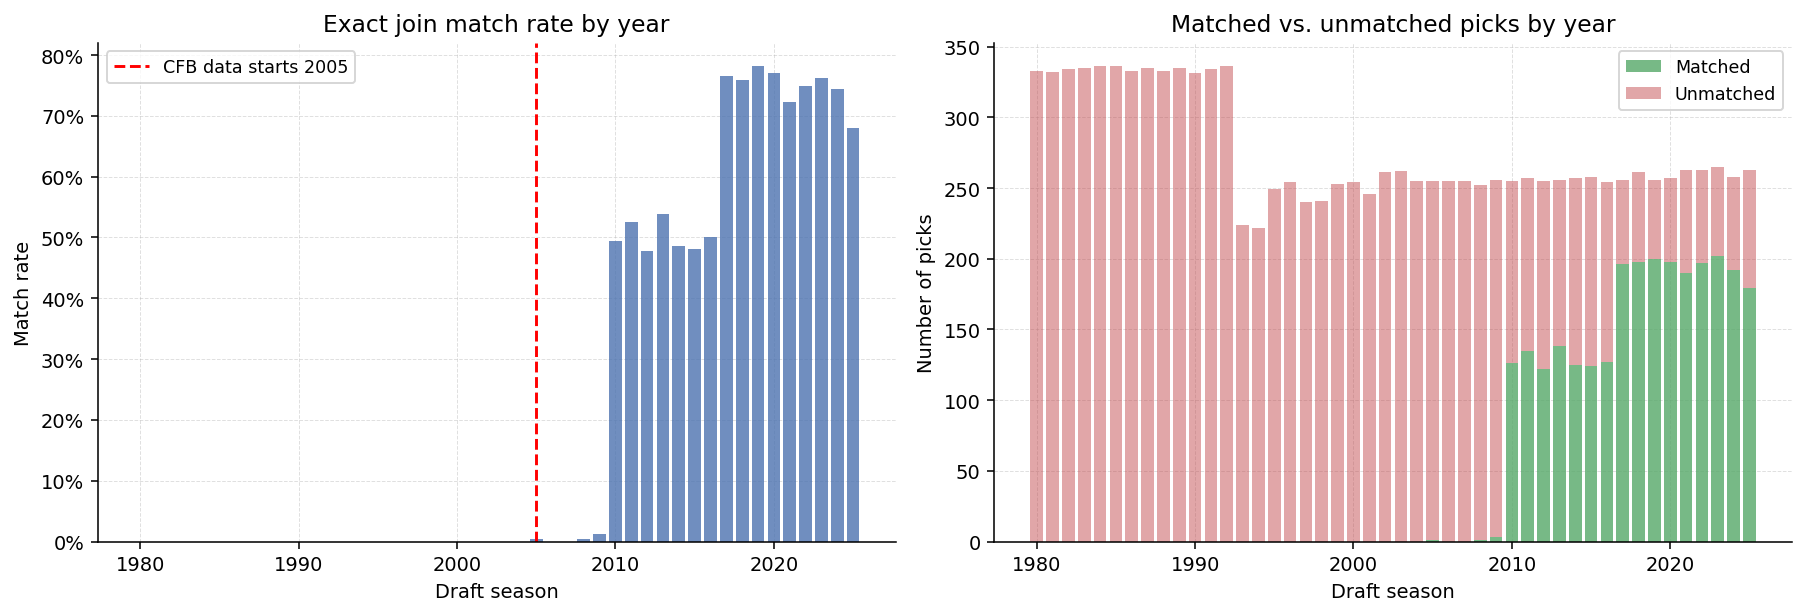


Overall: 2654 matched / 12670 total (20.9%)
In CFB window (2005, 2025): 2654 / 5407 (49.1%)


In [94]:
# ── 2.2 Match rate by draft year (exact join, no college filter) ───────────────
# We do the exact join and compute per-year match rates.
from src.model_v3.data_loader import CFB_STAT_COLS as _ALL_STAT_COLS

merged_exact, stats_exact = join_cfb_to_draft(
    draft, cfb, join_on_college=False, use_fuzzy=False)

stat_indicator = _ALL_STAT_COLS[0]  # use first stat col as match indicator
merged_exact['_matched'] = merged_exact[stat_indicator].notna()

by_year = (merged_exact.groupby('season')['_matched']
           .agg(total='count', matched='sum')
           .assign(match_rate=lambda x: x['matched'] / x['total']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=140)

ax = axes[0]
ax.bar(by_year.index, by_year['match_rate'], color='#4C72B0', alpha=0.8)
ax.axvline(cfb['draft_season'].min(), color='red', lw=1.5, ls='--', label=f'CFB data starts {cfb["draft_season"].min()}')
ax.set_xlabel('Draft season'); ax.set_ylabel('Match rate')
ax.set_title('Exact join match rate by year')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)
ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)

ax = axes[1]
ax.bar(by_year.index, by_year['matched'], color='#55A868', alpha=0.8, label='Matched')
ax.bar(by_year.index, by_year['total'] - by_year['matched'],
       bottom=by_year['matched'], color='#C44E52', alpha=0.5, label='Unmatched')
ax.set_xlabel('Draft season'); ax.set_ylabel('Number of picks')
ax.set_title('Matched vs. unmatched picks by year')
ax.legend(fontsize=9)
ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_join_match_by_year.png'), dpi=180)
plt.show()
print(f"\nOverall: {stats_exact['matched_total']} matched / {stats_exact['total_picks']} total "
      f"({stats_exact['match_rate_overall']:.1%})")
print(f"In CFB window {stats_exact['cfb_window']}: "
      f"{stats_exact['matched_in_window']} / {stats_exact['picks_in_window']} "
      f"({stats_exact['match_rate_in_window']:.1%})")

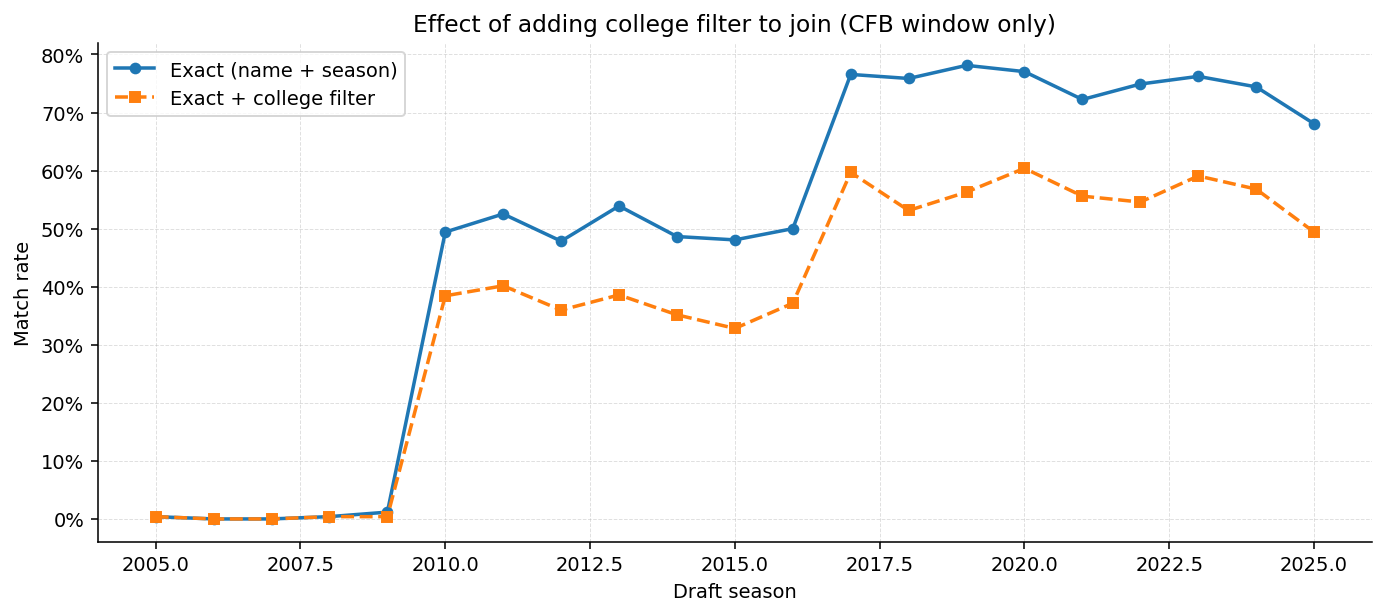

College filter drops 697 matches in window (26.3% of exact matches)


In [95]:
# ── 2.3 Impact of college filter ──────────────────────────────────────────────
merged_college, stats_college = join_cfb_to_draft(
    draft, cfb, join_on_college=True, use_fuzzy=False)
merged_college['_matched'] = merged_college[stat_indicator].notna()

by_year_col = (merged_college.groupby('season')['_matched']
               .agg(total='count', matched='sum')
               .assign(match_rate=lambda x: x['matched'] / x['total']))

# Window comparison
win = cfb['draft_season'].min()
in_win = by_year[by_year.index >= win]
in_win_col = by_year_col[by_year_col.index >= win]

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=140)
ax.plot(in_win.index, in_win['match_rate'], marker='o', lw=1.8, ms=5, label='Exact (name + season)')
ax.plot(in_win_col.index, in_win_col['match_rate'], marker='s', lw=1.8, ms=5,
        linestyle='--', label='Exact + college filter')
ax.set_xlabel('Draft season'); ax.set_ylabel('Match rate')
ax.set_title('Effect of adding college filter to join (CFB window only)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=10)
ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_join_college_impact.png'), dpi=180)
plt.show()

dropped = stats_exact['matched_in_window'] - stats_college['matched_in_window']
print(f"College filter drops {dropped} matches in window "
      f"({dropped / stats_exact['matched_in_window']:.1%} of exact matches)")

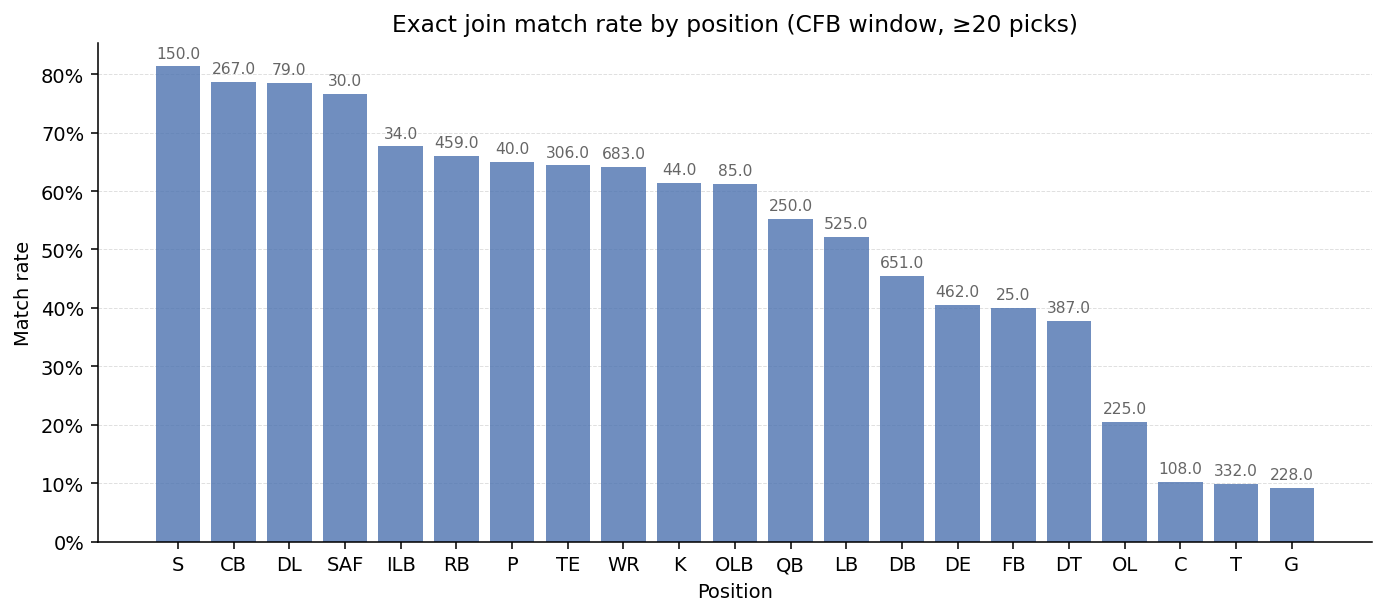

In [96]:
# ── 2.4 Match rate by position (exact join, CFB window) ───────────────────────
in_window_mask = merged_exact['season'].between(
    cfb['draft_season'].min(), cfb['draft_season'].max())
df_win = merged_exact[in_window_mask].copy()

if 'position' in df_win.columns:
    by_pos = (df_win.groupby('position')['_matched']
              .agg(total='count', matched='sum')
              .assign(match_rate=lambda x: x['matched'] / x['total'])
              .sort_values('match_rate', ascending=False))
    # Filter to positions with at least 20 picks
    by_pos = by_pos[by_pos['total'] >= 20]

    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=140)
    bars = ax.bar(by_pos.index, by_pos['match_rate'], color='#4C72B0', alpha=0.8)
    ax.set_xlabel('Position'); ax.set_ylabel('Match rate')
    ax.set_title('Exact join match rate by position (CFB window, ≥20 picks)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for bar, (_, row) in zip(bars, by_pos.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{row['total']}", ha='center', va='bottom', fontsize=8, color='0.4')
    ax.grid(True, axis='y', ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
    for s in ['top','right']: ax.spines[s].set_visible(False)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'plot_join_match_by_position.png'), dpi=180)
    plt.show()

In [97]:
# ── 2.5 Sample matched and unmatched picks ────────────────────────────────────
in_window_mask2 = merged_exact['season'] >= cfb['draft_season'].min()
matched_sample   = merged_exact[in_window_mask2 & merged_exact['_matched']]
unmatched_sample = merged_exact[in_window_mask2 & ~merged_exact['_matched']]

show_cols = ['season', 'pfr_player_name', 'position', 'college', 'pick']
show_cols = [c for c in show_cols if c in merged_exact.columns]

print('=== 10 matched picks ===')
print(matched_sample[show_cols].head(10).to_string(index=False))
print()
print('=== 10 unmatched picks ===')
print(unmatched_sample[show_cols].head(10).to_string(index=False))

=== 10 matched picks ===
 season pfr_player_name position          college  pick
   2005   Justin Miller       DB          Clemson    57
   2008  Spencer Larsen       LB          Arizona   183
   2009  Jason Williams       LB Western Illinois    69
   2009   Robert Henson       LB              TCU   186
   2009      Brad Jones       LB         Colorado   218
   2010    Sam Bradford       QB         Oklahoma     1
   2010   Ndamukong Suh       DT         Nebraska     2
   2010      Eric Berry       DB        Tennessee     5
   2010       Joe Haden       DB          Florida     7
   2010 Rolando McClain       LB          Alabama     8

=== 10 unmatched picks ===
 season   pfr_player_name position        college  pick
   2005        Alex Smith       QB           Utah     1
   2005      Ronnie Brown       RB         Auburn     2
   2005   Braylon Edwards       WR       Michigan     3
   2005     Cedric Benson       RB          Texas     4
   2005 Cadillac Williams       RB         Auburn  

## 3. Build Modeling Dataset

Uses the join strategy configured at the top (`JOIN_ON_COLLEGE`, `USE_FUZZY`).  
Attaches AV labels and drops rows without a 2-year AV target.

In [98]:
merged, join_stats = join_cfb_to_draft(
    draft, cfb,
    join_on_college=JOIN_ON_COLLEGE,
    use_fuzzy=USE_FUZZY,
    fuzzy_threshold=FUZZY_THRESHOLD,
)

df = merged.rename(columns={'season': 'draft_season'}).merge(
    labels, on=['draft_season', 'pfr_player_id'], how='left'
)
df = df.dropna(subset=['av_2yr']).copy()
df['av_2yr'] = df['av_2yr'].astype(float)

cfb_matched_pct = df[CFB_STAT_COLS[0]].notna().mean()
print(f'Dataset: {len(df):,} rows  |  years {df.draft_season.min()}–{df.draft_season.max()}')
print(f'Target av_2yr: mean={df.av_2yr.mean():.2f}  std={df.av_2yr.std():.2f}  max={df.av_2yr.max():.0f}')
print(f'CFB features filled: {cfb_matched_pct:.1%} of rows')
print(f'Join stats: {join_stats}')
df.head()

Dataset: 4,739 rows  |  years 1999–2024
Target av_2yr: mean=6.35  std=5.61  max=41
CFB features filled: 42.1% of rows
Join stats: {'total_picks': 12670, 'cfb_window': (2005, 2025), 'picks_in_window': 5407, 'matched_total': 2654, 'matched_in_window': 2654, 'match_rate_overall': 0.20879553142947055, 'match_rate_in_window': 0.49084520066580356, 'join_on_college': False, 'use_fuzzy': False}


,draft_season,pick,round,team,position,category,side,age,college,pfr_player_id,...,punting_no,punting_yds,punting_ypp,kickreturns_no,kickreturns_yds,kickreturns_avg,puntreturns_no,puntreturns_yds,puntreturns_avg,av_2yr
5773,1999,1,1,CLE,QB,QB,O,22.0,Kentucky,CoucTi00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5774,1999,2,1,PHI,QB,QB,O,22.0,Syracuse,McNaDo00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0
5775,1999,3,1,CIN,QB,QB,O,24.0,Oregon,SmitAk00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
5776,1999,4,1,IND,RB,RB,O,21.0,Miami (FL),JameEd00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.0
5777,1999,5,1,NOR,RB,RB,O,22.0,Texas,WillRi00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0


## 4. Preprocessing Helpers

In [99]:
def build_spline_preprocessor(df_train):
    """SplineTransformer on pick, median imputation on all other numerics, OHE on cats."""
    num_cols = [c for c in NUM_COLS if c in df_train.columns]
    cat_cols = [c for c in CAT_COLS if c in df_train.columns]
    transformers = []
    if 'pick' in num_cols:
        transformers.append(('pick_spline', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('spl', SplineTransformer(n_knots=6, degree=3, include_bias=False)),
        ]), ['pick']))
        rest = [c for c in num_cols if c != 'pick']
        if rest:
            transformers.append(('num', SimpleImputer(strategy='median'), rest))
    elif num_cols:
        transformers.append(('num', SimpleImputer(strategy='median'), num_cols))
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))
    return ColumnTransformer(transformers, remainder='drop'), num_cols, cat_cols


def build_tree_preprocessor(df_train):
    """Median imputation on numerics, OHE on cats (no spline needed for trees)."""
    num_cols = [c for c in NUM_COLS if c in df_train.columns]
    cat_cols = [c for c in CAT_COLS if c in df_train.columns]
    transformers = []
    if num_cols:
        transformers.append(('num', SimpleImputer(strategy='median'), num_cols))
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))
    return ColumnTransformer(transformers, remainder='drop'), num_cols, cat_cols


def build_embed_data(df_tr, df_te):
    """Prepare separate numeric + ordinal-encoded categorical arrays for embedding models."""
    num_cols = [c for c in NUM_COLS if c in df_tr.columns]
    cat_cols = [c for c in CAT_COLS if c in df_tr.columns]

    num_imp  = SimpleImputer(strategy='median')
    X_num_tr = num_imp.fit_transform(df_tr[num_cols]).astype(np.float32)
    X_num_te = num_imp.transform(df_te[num_cols]).astype(np.float32)

    cat_tr = df_tr[cat_cols].fillna('__nan__').astype(str)
    cat_te = df_te[cat_cols].fillna('__nan__').astype(str)
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.int64)
    X_cat_tr = enc.fit_transform(cat_tr)
    X_cat_te = enc.transform(cat_te)

    cardinalities = [len(cats) + 1 for cats in enc.categories_]  # +1 for unknown slot
    for j in range(X_cat_tr.shape[1]):
        X_cat_tr[X_cat_tr[:, j] == -1, j] = cardinalities[j] - 1
        X_cat_te[X_cat_te[:, j] == -1, j] = cardinalities[j] - 1

    return X_num_tr, X_num_te, X_cat_tr, X_cat_te, cardinalities


def get_feature_names(pre, num_cols, cat_cols):
    names = list(num_cols)
    if cat_cols and 'cat' in pre.named_transformers_:
        names += list(pre.named_transformers_['cat'].get_feature_names_out(cat_cols))
    return names


def to_tensor(arr):
    return torch.tensor(arr.astype(np.float32))


def eval_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    sp   = float(spearmanr(y_true, y_pred).correlation)
    return mae, rmse, sp


print('Preprocessing helpers defined.')

Preprocessing helpers defined.


## 5. TabNet Training Loop

In [100]:
def train_one_fold(X_tr, y_tr, n_features, verbose=True):
    model = TabNetRegressor(n_features=n_features, **TABNET_CFG).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=TRAIN_CFG['lr'])
    scheduler = ExponentialLR(optimizer, gamma=TRAIN_CFG['lr_decay'])

    n_val = max(1, int(len(X_tr) * TRAIN_CFG['val_fraction']))
    Xt, Xv = X_tr[:-n_val], X_tr[-n_val:]
    yt, yv = y_tr[:-n_val], y_tr[-n_val:]

    loader = DataLoader(TensorDataset(to_tensor(Xt), to_tensor(yt)),
                        batch_size=TRAIN_CFG['batch_size'], shuffle=True, drop_last=True)
    Xv_t, yv_t = to_tensor(Xv).to(DEVICE), to_tensor(yv).to(DEVICE)

    best_val, best_state, patience_ctr = float('inf'), None, 0
    train_hist, val_hist = [], []
    step = 0

    for epoch in range(TRAIN_CFG['max_epochs']):
        model.train()
        ep_loss = 0.0
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred, sp, _ = model(Xb)
            loss = model.loss(pred, yb, sp)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
            step += 1
            if step % TRAIN_CFG['lr_decay_steps'] == 0:
                scheduler.step()
        train_hist.append(ep_loss / max(1, len(loader)))

        model.eval()
        with torch.no_grad():
            vp, vsp, _ = model(Xv_t)
            vl = model.loss(vp, yv_t, vsp).item()
        val_hist.append(vl)

        if vl < best_val:
            best_val, patience_ctr = vl, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if verbose and (epoch + 1) % 100 == 0:
            print(f'  epoch {epoch+1:4d}  train={train_hist[-1]:.3f}  val={vl:.3f}  '
                  f'best={best_val:.3f}  patience={patience_ctr}/{TRAIN_CFG["patience"]}')

        if patience_ctr >= TRAIN_CFG['patience']:
            if verbose: print(f'  Early stop at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    return model, train_hist, val_hist

print('Training loop defined.')

Training loop defined.


In [101]:
def train_embed_model(model, X_num_tr, X_cat_tr, y_tr, verbose=False):
    """Shared training loop for MLPWithEmbeddings and FTTransformer."""
    n_val = max(1, int(len(y_tr) * EMBED_TRAIN_CFG['val_fraction']))
    Xn_t, Xn_v = X_num_tr[:-n_val], X_num_tr[-n_val:]
    Xc_t, Xc_v = X_cat_tr[:-n_val], X_cat_tr[-n_val:]
    yt, yv = y_tr[:-n_val], y_tr[-n_val:]

    loader = DataLoader(
        TensorDataset(
            torch.tensor(Xn_t, dtype=torch.float32),
            torch.tensor(Xc_t, dtype=torch.long),
            torch.tensor(yt,   dtype=torch.float32),
        ),
        batch_size=EMBED_TRAIN_CFG['batch_size'], shuffle=True, drop_last=False,
    )
    Xn_v_t = torch.tensor(Xn_v, dtype=torch.float32).to(DEVICE)
    Xc_v_t = torch.tensor(Xc_v, dtype=torch.long).to(DEVICE)
    yv_t   = torch.tensor(yv,   dtype=torch.float32).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=EMBED_TRAIN_CFG['lr'], weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EMBED_TRAIN_CFG['max_epochs'])

    best_val, best_state, patience_ctr = float('inf'), None, 0

    for epoch in range(EMBED_TRAIN_CFG['max_epochs']):
        model.train()
        for Xb_n, Xb_c, yb in loader:
            Xb_n, Xb_c, yb = Xb_n.to(DEVICE), Xb_c.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            F.mse_loss(model(Xb_n, Xb_c), yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(model(Xn_v_t, Xc_v_t), yv_t).item()

        if val_loss < best_val:
            best_val, patience_ctr = val_loss, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if verbose and (epoch + 1) % 50 == 0:
            print(f'  epoch {epoch+1:4d}  val={val_loss:.3f}  best={best_val:.3f}  '
                  f'patience={patience_ctr}/{EMBED_TRAIN_CFG["patience"]}')

        if patience_ctr >= EMBED_TRAIN_CFG['patience']:
            if verbose: print(f'  Early stop at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    return model

print('Embed-model training loop defined.')

Embed-model training loop defined.


## 6. Walk-forward Evaluation — All Six Models

In [102]:
set_seeds()  # reset seed before walk-forward so results are reproducible on re-runs

feat_cols = [c for c in (NUM_COLS + CAT_COLS) if c in df.columns]
X_raw = df[feat_cols].copy()
y     = df['av_2yr'].values
years = df['draft_season'].values

unique_years = sorted(np.unique(years))
test_years   = [yr for yr in unique_years if yr > WALK_FORWARD_START_YEAR]
print(f'Test years: {test_years[:5]} ... {test_years[-3:]}')
print(f'Total folds: {len(test_years)}')

results = []
last = {}
latest_year = max(test_years)

for test_year in test_years:
    tr_mask = (years >= WALK_FORWARD_START_YEAR) & (years < test_year)
    te_mask = years == test_year
    X_tr_raw, X_te_raw = X_raw[tr_mask], X_raw[te_mask]
    y_tr, y_te = y[tr_mask], y[te_mask]

    print(f'\n=== Test {test_year}  train={tr_mask.sum()}  test={te_mask.sum()} ===')

    # ── Spline Ridge ──────────────────────────────────────────────────────────
    pre_s, _, _ = build_spline_preprocessor(X_tr_raw)
    spline_pipe = Pipeline([('pre', pre_s), ('reg', Ridge(alpha=1.0))])
    spline_pipe.fit(X_tr_raw, y_tr)
    pred_s = spline_pipe.predict(X_te_raw)
    mae_s, rmse_s, sp_s = eval_metrics(y_te, pred_s)
    print(f'  Spline   MAE={mae_s:.3f}  RMSE={rmse_s:.3f}  Spearman={sp_s:.3f}')

    # ── XGBoost ───────────────────────────────────────────────────────────────
    pre_x, _num_x, _cat_x = build_tree_preprocessor(X_tr_raw)
    xgb_pipe = Pipeline([
        ('pre', pre_x),
        ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                              subsample=0.8, colsample_bytree=0.8,
                              reg_lambda=1.0, random_state=SEED)),
    ])
    xgb_pipe.fit(X_tr_raw, y_tr)
    pred_x = xgb_pipe.predict(X_te_raw)
    mae_x, rmse_x, sp_x = eval_metrics(y_te, pred_x)
    print(f'  XGBoost  MAE={mae_x:.3f}  RMSE={rmse_x:.3f}  Spearman={sp_x:.3f}')

    # ── LightGBM ──────────────────────────────────────────────────────────────
    pre_lgbm, _num_lgbm, _cat_lgbm = build_tree_preprocessor(X_tr_raw)
    lgbm_pipe = Pipeline([
        ('pre', pre_lgbm),
        ('lgbm', LGBMRegressor(**LGBM_CFG)),
    ])
    lgbm_pipe.fit(X_tr_raw, y_tr)
    pred_lgbm = lgbm_pipe.predict(X_te_raw)
    mae_lgbm, rmse_lgbm, sp_lgbm = eval_metrics(y_te, pred_lgbm)
    print(f'  LightGBM MAE={mae_lgbm:.3f}  RMSE={rmse_lgbm:.3f}  Spearman={sp_lgbm:.3f}')

    # ── Random Forest ─────────────────────────────────────────────────────────
    pre_rf, _num_rf, _cat_rf = build_tree_preprocessor(X_tr_raw)
    rf_pipe = Pipeline([
        ('pre', pre_rf),
        ('rf', RandomForestRegressor(**RF_CFG)),
    ])
    rf_pipe.fit(X_tr_raw, y_tr)
    pred_rf = rf_pipe.predict(X_te_raw)
    mae_rf, rmse_rf, sp_rf = eval_metrics(y_te, pred_rf)
    print(f'  RF       MAE={mae_rf:.3f}  RMSE={rmse_rf:.3f}  Spearman={sp_rf:.3f}')

    # ── CatBoost ──────────────────────────────────────────────────────────────
    _num_cb = [c for c in NUM_COLS if c in X_tr_raw.columns]
    _cat_cb = [c for c in CAT_COLS if c in X_tr_raw.columns]
    _all_cb = _num_cb + _cat_cb
    _cat_idx_cb = list(range(len(_num_cb), len(_num_cb) + len(_cat_cb)))
    X_tr_cb = X_tr_raw[_all_cb].copy()
    X_te_cb = X_te_raw[_all_cb].copy()
    for c in _cat_cb:
        X_tr_cb[c] = X_tr_cb[c].fillna('nan').astype(str)
        X_te_cb[c] = X_te_cb[c].fillna('nan').astype(str)
    cb_model = CatBoostRegressor(**CATBOOST_CFG, cat_features=_cat_idx_cb)
    cb_model.fit(X_tr_cb, y_tr)
    pred_cb = cb_model.predict(X_te_cb)
    mae_cb, rmse_cb, sp_cb = eval_metrics(y_te, pred_cb)
    print(f'  CatBoost MAE={mae_cb:.3f}  RMSE={rmse_cb:.3f}  Spearman={sp_cb:.3f}')

    # ── MLPE + FT-Transformer (shared embed preprocessing) ────────────────────
    X_num_tr, X_num_te, X_cat_tr, X_cat_te, cardinalities = build_embed_data(X_tr_raw, X_te_raw)

    mlpe = MLPWithEmbeddings(X_num_tr.shape[1], cardinalities, **MLPE_CFG).to(DEVICE)
    mlpe = train_embed_model(mlpe, X_num_tr, X_cat_tr, y_tr, verbose=False)
    mlpe.eval()
    with torch.no_grad():
        pred_mlpe = mlpe(
            torch.tensor(X_num_te, dtype=torch.float32).to(DEVICE),
            torch.tensor(X_cat_te, dtype=torch.long).to(DEVICE),
        ).cpu().numpy()
    mae_mlpe, rmse_mlpe, sp_mlpe = eval_metrics(y_te, pred_mlpe)
    print(f'  MLPE     MAE={mae_mlpe:.3f}  RMSE={rmse_mlpe:.3f}  Spearman={sp_mlpe:.3f}')

    ftt = FTTransformer(X_num_tr.shape[1], cardinalities, **FTT_CFG).to(DEVICE)
    ftt = train_embed_model(ftt, X_num_tr, X_cat_tr, y_tr, verbose=False)
    ftt.eval()
    with torch.no_grad():
        pred_ftt = ftt(
            torch.tensor(X_num_te, dtype=torch.float32).to(DEVICE),
            torch.tensor(X_cat_te, dtype=torch.long).to(DEVICE),
        ).cpu().numpy()
    mae_ftt, rmse_ftt, sp_ftt = eval_metrics(y_te, pred_ftt)
    print(f'  FTT      MAE={mae_ftt:.3f}  RMSE={rmse_ftt:.3f}  Spearman={sp_ftt:.3f}')

    # ── TabNet ────────────────────────────────────────────────────────────────
    pre_t, _num_t, _cat_t = build_tree_preprocessor(X_tr_raw)
    X_tr_t = pre_t.fit_transform(X_tr_raw).astype(np.float32)
    X_te_t = pre_t.transform(X_te_raw).astype(np.float32)
    feat_names_t = get_feature_names(pre_t, _num_t, _cat_t)

    tabnet, th, vh = train_one_fold(X_tr_t, y_tr, X_tr_t.shape[1], verbose=True)
    tabnet.eval()
    with torch.no_grad():
        Xte_ten = to_tensor(X_te_t).to(DEVICE)
        pred_raw, _, masks = tabnet(Xte_ten)
        pred_t = pred_raw.cpu().numpy()
        importance = tabnet.encoder.aggregate_importance(masks).cpu().numpy()
    mae_t, rmse_t, sp_t = eval_metrics(y_te, pred_t)
    print(f'  TabNet   MAE={mae_t:.3f}  RMSE={rmse_t:.3f}  Spearman={sp_t:.3f}')

    results.append({
        'test_year': int(test_year), 'n_test': int(te_mask.sum()),
        'spline_mae':   mae_s,      'spline_rmse':   rmse_s,      'spline_spearman':   sp_s,
        'xgb_mae':      mae_x,      'xgb_rmse':      rmse_x,      'xgb_spearman':      sp_x,
        'lgbm_mae':     mae_lgbm,   'lgbm_rmse':     rmse_lgbm,   'lgbm_spearman':     sp_lgbm,
        'rf_mae':       mae_rf,     'rf_rmse':        rmse_rf,     'rf_spearman':       sp_rf,
        'catboost_mae': mae_cb,     'catboost_rmse': rmse_cb,     'catboost_spearman': sp_cb,
        'mlpe_mae':     mae_mlpe,   'mlpe_rmse':     rmse_mlpe,   'mlpe_spearman':     sp_mlpe,
        'ftt_mae':      mae_ftt,    'ftt_rmse':      rmse_ftt,    'ftt_spearman':      sp_ftt,
        'tabnet_mae':   mae_t,      'tabnet_rmse':   rmse_t,      'tabnet_spearman':   sp_t,
    })

    if test_year == latest_year:
        last = dict(
            y_te=y_te,
            pred_s=pred_s, pred_x=pred_x, pred_lgbm=pred_lgbm, pred_rf=pred_rf,
            pred_cb=pred_cb, pred_mlpe=pred_mlpe, pred_ftt=pred_ftt, pred_t=pred_t,
            importance=importance, feat_names=feat_names_t,
            xgb_pipe=xgb_pipe, num_x=_num_x, cat_x=_cat_x,
            lgbm_pipe=lgbm_pipe, num_lgbm=_num_lgbm, cat_lgbm=_cat_lgbm,
            rf_pipe=rf_pipe, num_rf=_num_rf, cat_rf=_cat_rf,
            cb_model=cb_model, cb_feat_names=_all_cb,
            train_hist=th, val_hist=vh,
        )

res_df = pd.DataFrame(results)
print('\n=== Walk-forward summary ===')
print(res_df.to_string(index=False))
res_df.to_csv(os.path.join(OUT_DIR, 'walkforward_results_v3.csv'), index=False)

Test years: [2009, 2010, 2011, 2012, 2013] ... [2022, 2023, 2024]
Total folds: 16

=== Test 2009  train=169  test=174 ===
  Spline   MAE=3.968  RMSE=5.111  Spearman=0.406


/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['passing_pct' 'passing_ypa' 'rushing_ypc' 'receiving_ypr' 'kicking_pct'
 'punting_ypp' 'kickreturns_avg' 'puntreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['passing_pct' 'passing_ypa' 'rushing_ypc' 'receiving_ypr' 'kicking_pct'
 'punting_ypp' 'kickreturns_avg' 'puntreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['passing_pct' 'passing_ypa' 'rushing_ypc' 'receiving_ypr' 'kicking_pct'
 'punting_ypp' '

  XGBoost  MAE=3.962  RMSE=5.251  Spearman=0.439


/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['passing_pct' 'passing_ypa' 'rushing_ypc' 'receiving_ypr' 'kicking_pct'
 'punting_ypp' 'kickreturns_avg' 'puntreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['passing_pct' 'passing_ypa' 'rushing_ypc' 'receiving_ypr' 'kicking_pct'
 'punting_ypp' 'kickreturns_avg' 'puntreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


  LightGBM MAE=3.593  RMSE=4.753  Spearman=0.477


...

  LightGBM MAE=3.770  RMSE=4.965  Spearman=0.436
  RF       MAE=3.541  RMSE=4.593  Spearman=0.518
  CatBoost MAE=3.596  RMSE=4.703  Spearman=0.508
  MLPE     MAE=3.442  RMSE=4.625  Spearman=0.527
  FTT      MAE=3.538  RMSE=4.687  Spearman=0.501
  Early stop at epoch 86
  TabNet   MAE=4.384  RMSE=5.294  Spearman=0.207

=== Test 2023  train=2806  test=211 ===
  Spline   MAE=3.271  RMSE=4.332  Spearman=0.543
  XGBoost  MAE=3.182  RMSE=4.264  Spearman=0.567


/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  LightGBM MAE=3.410  RMSE=4.518  Spearman=0.482
  RF       MAE=3.168  RMSE=4.141  Spearman=0.576
  CatBoost MAE=3.132  RMSE=4.152  Spearman=0.592
  MLPE     MAE=3.037  RMSE=4.195  Spearman=0.572
  FTT      MAE=3.117  RMSE=4.091  Spearman=0.608
  Early stop at epoch 92
  TabNet   MAE=3.120  RMSE=4.156  Spearman=0.594

=== Test 2024  train=3017  test=192 ===
  Spline   MAE=3.019  RMSE=3.771  Spearman=0.641
  XGBoost  MAE=2.989  RMSE=3.869  Spearman=0.624


/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  LightGBM MAE=3.153  RMSE=4.061  Spearman=0.556
  RF       MAE=2.994  RMSE=3.801  Spearman=0.623
  CatBoost MAE=3.055  RMSE=3.881  Spearman=0.625
  MLPE     MAE=3.054  RMSE=4.083  Spearman=0.615
  FTT      MAE=3.076  RMSE=4.085  Spearman=0.639
  Early stop at epoch 76
  TabNet   MAE=3.079  RMSE=3.919  Spearman=0.610

=== Walk-forward summary ===
 test_year  n_test  spline_mae  spline_rmse  spline_spearman  xgb_mae  xgb_rmse  xgb_spearman  lgbm_mae  lgbm_rmse  lgbm_spearman   rf_mae  rf_rmse  rf_spearman  catboost_mae  catboost_rmse  catboost_spearman  mlpe_mae  mlpe_rmse  mlpe_spearman  ftt_mae  ftt_rmse  ftt_spearman  tabnet_mae  tabnet_rmse  tabnet_spearman
      2009     174    3.968334     5.111444         0.405757 3.961667  5.251212      0.438591  3.593148   4.753434       0.477104 3.401848 4.455952     0.498904      3.552785       4.774186           0.458506  6.387112   8.225669       0.514181 3.487660  4.810906      0.511003    6.051778     8.039464         0.478036
      2010 

## 7. Loss Curves (final fold)

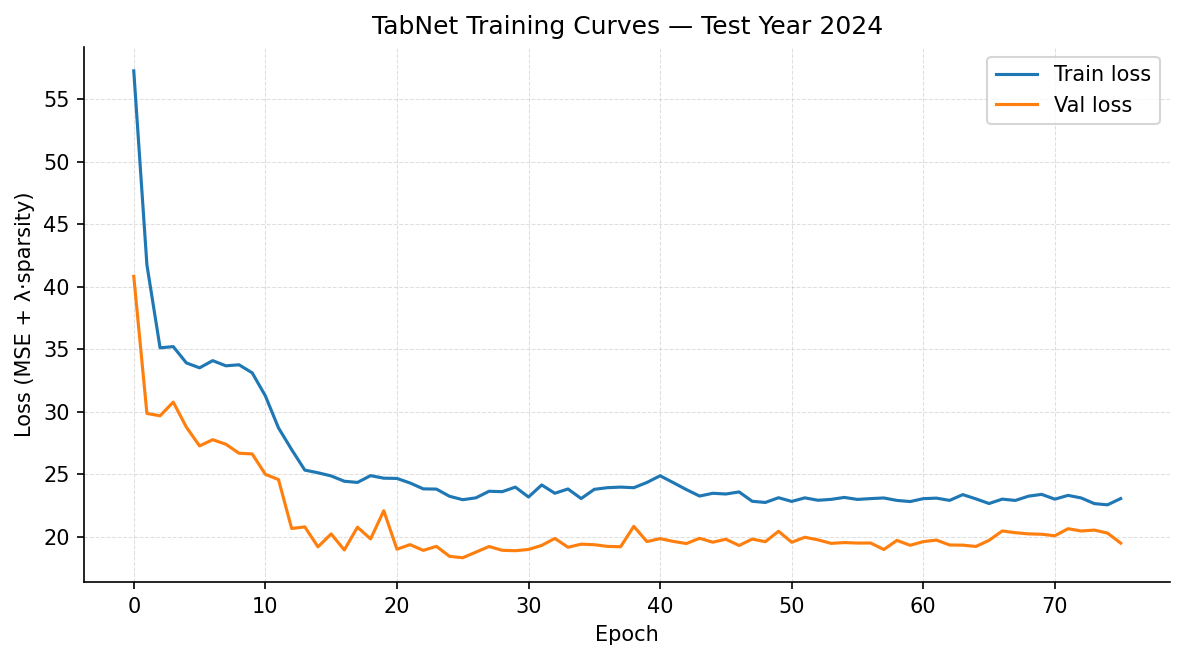

In [103]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
ax.plot(last['train_hist'], label='Train loss', lw=1.5)
ax.plot(last['val_hist'],   label='Val loss',   lw=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (MSE + λ·sparsity)')
ax.set_title(f'TabNet Training Curves — Test Year {latest_year}')
ax.legend()
ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'plot_tabnet_loss_curves_{latest_year}.png'), dpi=180)
plt.show()

## 8. Predicted vs. Actual (final fold)

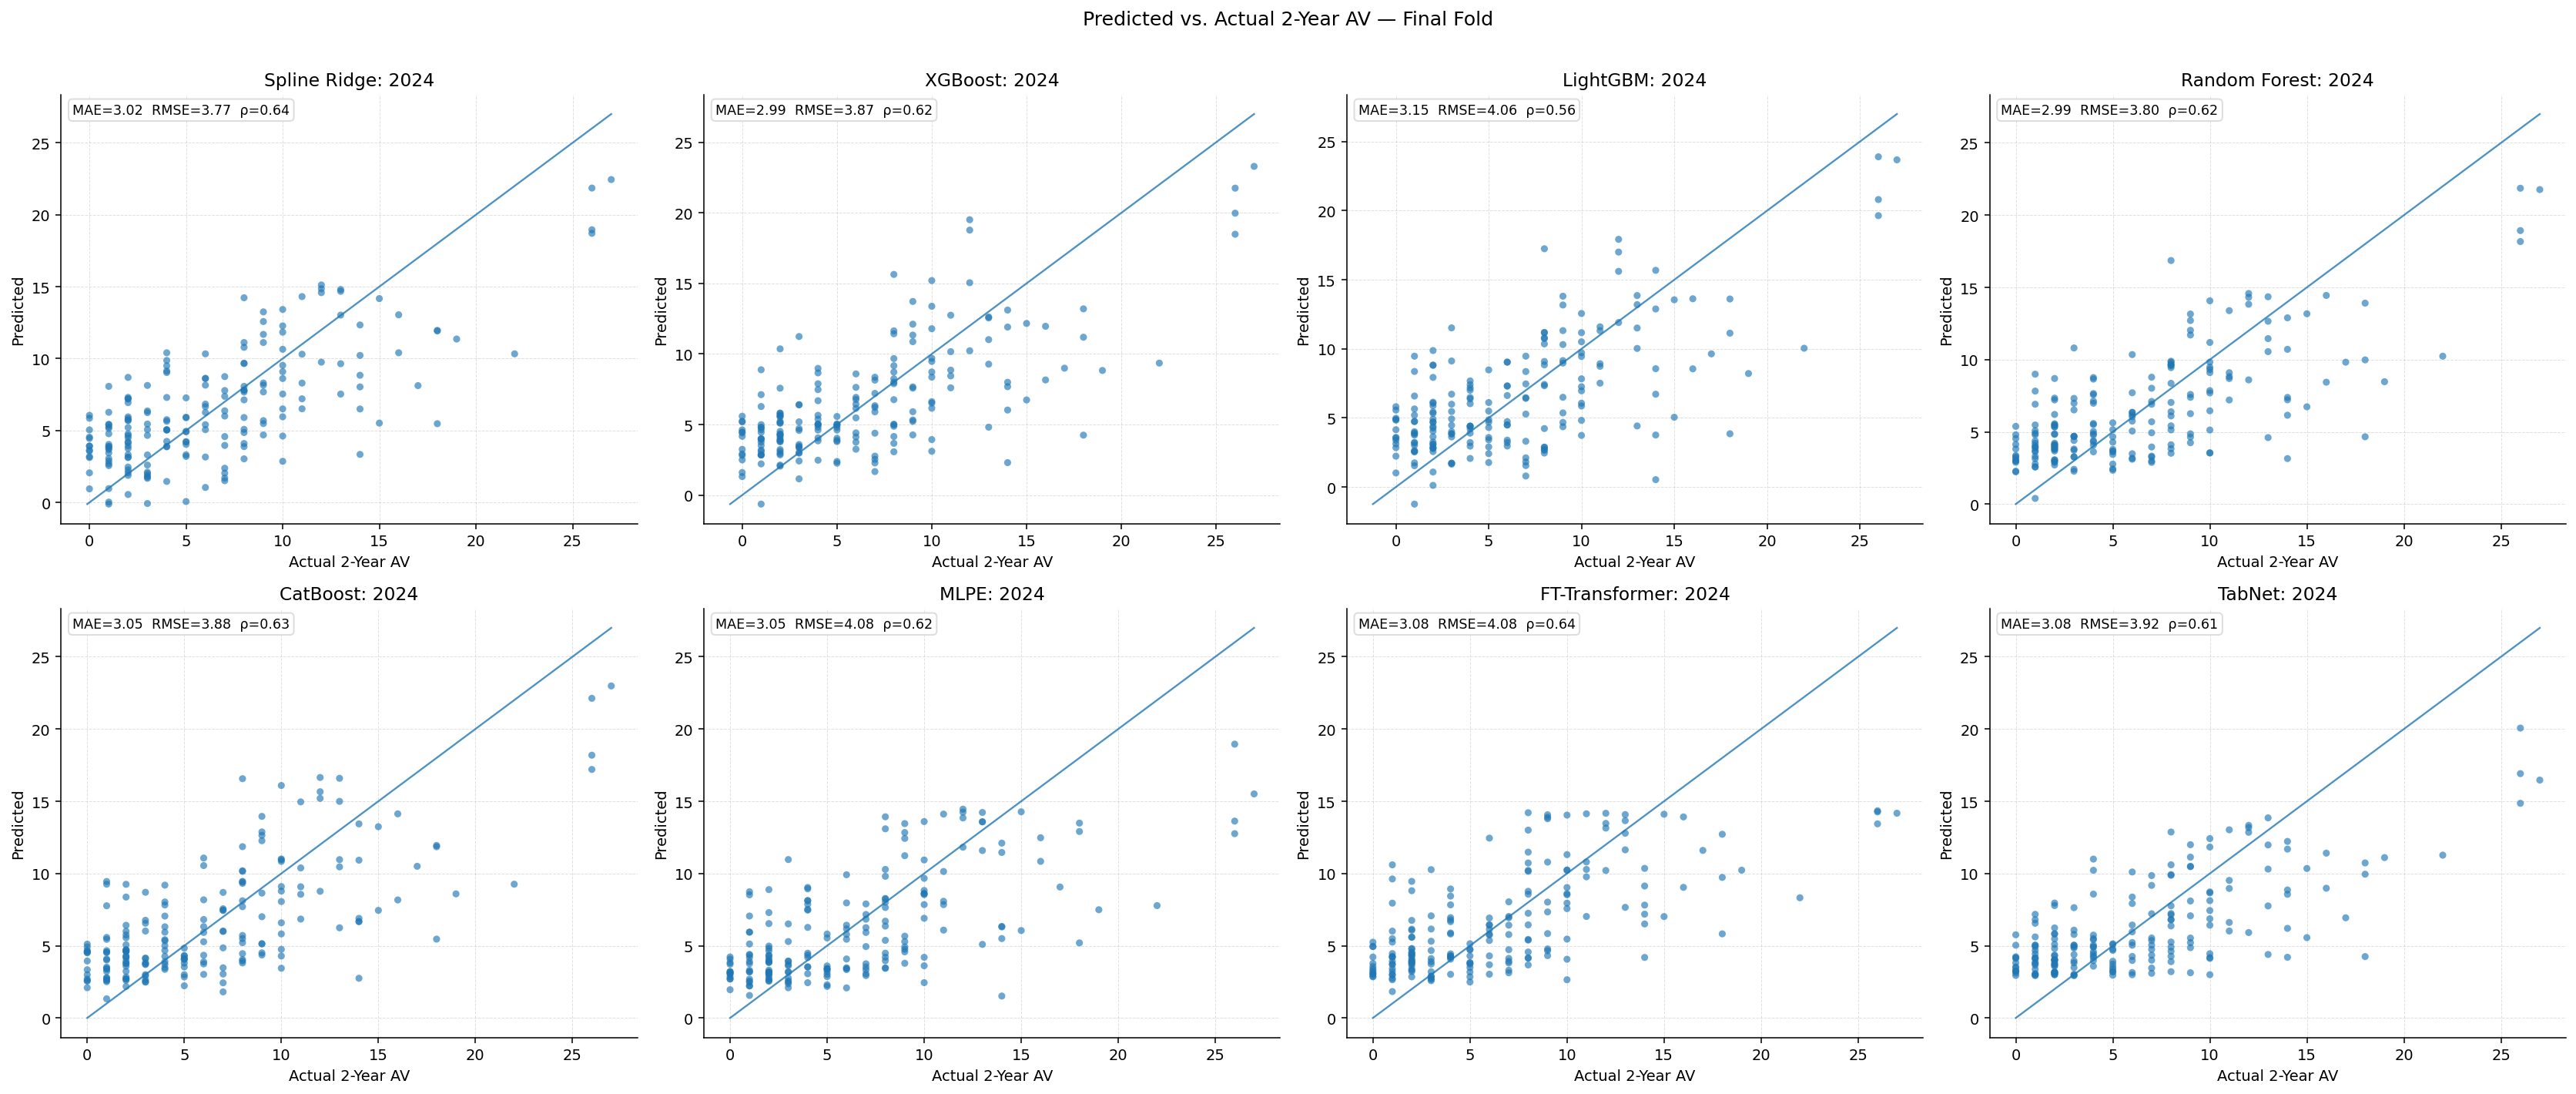

In [104]:
def plot_pred_vs_actual(y_true, y_pred, title, ax=None):
    mae, rmse, sp = eval_metrics(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5), dpi=140)
    ax.scatter(y_true, y_pred, s=22, alpha=0.65, edgecolor='none')
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], lw=1.2, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Actual 2-Year AV'); ax.set_ylabel('Predicted')
    ax.text(0.02, 0.98, f'MAE={mae:.2f}  RMSE={rmse:.2f}  ρ={sp:.2f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.9, ec='0.85'))
    ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
    for s in ['top','right']: ax.spines[s].set_visible(False)

fig, axes = plt.subplots(2, 4, figsize=(24, 10), dpi=140)
plot_pred_vs_actual(last['y_te'], last['pred_s'],    f'Spline Ridge: {latest_year}',    axes[0, 0])
plot_pred_vs_actual(last['y_te'], last['pred_x'],    f'XGBoost: {latest_year}',         axes[0, 1])
plot_pred_vs_actual(last['y_te'], last['pred_lgbm'], f'LightGBM: {latest_year}',        axes[0, 2])
plot_pred_vs_actual(last['y_te'], last['pred_rf'],   f'Random Forest: {latest_year}',   axes[0, 3])
plot_pred_vs_actual(last['y_te'], last['pred_cb'],   f'CatBoost: {latest_year}',        axes[1, 0])
plot_pred_vs_actual(last['y_te'], last['pred_mlpe'], f'MLPE: {latest_year}',            axes[1, 1])
plot_pred_vs_actual(last['y_te'], last['pred_ftt'],  f'FT-Transformer: {latest_year}',  axes[1, 2])
plot_pred_vs_actual(last['y_te'], last['pred_t'],    f'TabNet: {latest_year}',          axes[1, 3])
fig.suptitle('Predicted vs. Actual 2-Year AV — Final Fold', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'plot_pred_vs_actual_{latest_year}.png'), dpi=180)
plt.show()

## 9. Feature Importance (final fold)

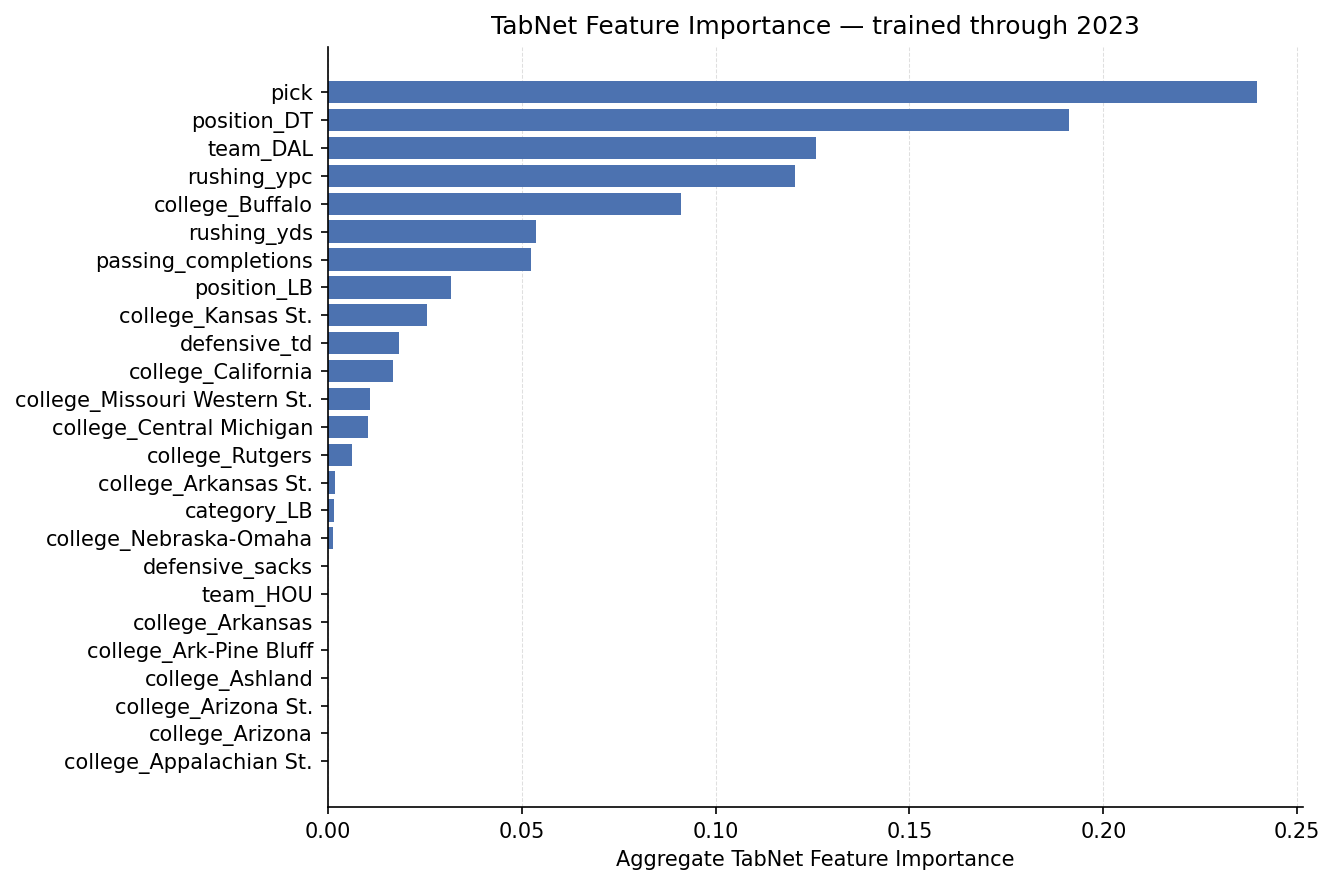

Top-10 features (TabNet):
   1. pick                                     0.2396
   2. position_DT                              0.1911
   3. team_DAL                                 0.1260
   4. rushing_ypc                              0.1205
   5. college_Buffalo                          0.0911
   6. rushing_yds                              0.0537
   7. passing_completions                      0.0523
   8. position_LB                              0.0319
   9. college_Kansas St.                       0.0257
  10. defensive_td                             0.0183


In [105]:
# TabNet aggregate attention importance
top_n = 25
idx = np.argsort(last['importance'])[::-1][:top_n]

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
ax.barh([last['feat_names'][i] for i in reversed(idx)],
         last['importance'][list(reversed(idx))], color='#4C72B0')
ax.set_xlabel('Aggregate TabNet Feature Importance')
ax.set_title(f'TabNet Feature Importance — trained through {latest_year-1}')
ax.grid(True, axis='x', ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_tabnet_feature_importance.png'), dpi=180)
plt.show()

print('Top-10 features (TabNet):')
for rank, i in enumerate(idx[:10], 1):
    print(f'  {rank:2d}. {last["feat_names"][i]:<40s} {last["importance"][i]:.4f}')

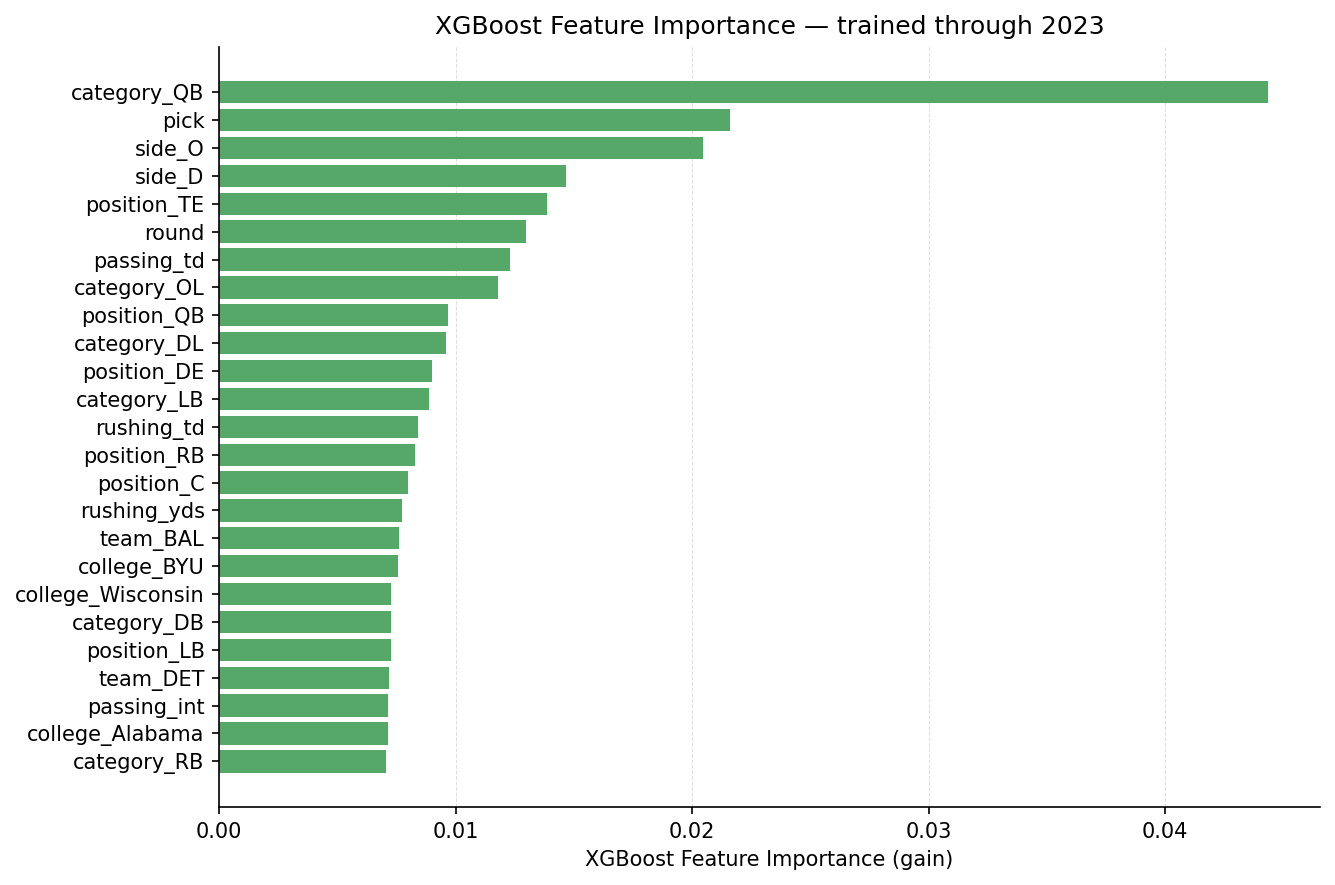

Top-10 features (XGBoost):
   1. category_QB                              0.0443
   2. pick                                     0.0216
   3. side_O                                   0.0205
   4. side_D                                   0.0147
   5. position_TE                              0.0139
   6. round                                    0.0130
   7. passing_td                               0.0123
   8. category_OL                              0.0118
   9. position_QB                              0.0097
  10. category_DL                              0.0096


In [106]:
# XGBoost feature importance
xgb_imp = last['xgb_pipe'].named_steps['xgb'].feature_importances_
xgb_names = get_feature_names(
    last['xgb_pipe'].named_steps['pre'], last['num_x'], last['cat_x'])

idx_x = np.argsort(xgb_imp)[::-1][:top_n]
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
ax.barh([xgb_names[i] for i in reversed(idx_x)],
         xgb_imp[list(reversed(idx_x))], color='#55A868')
ax.set_xlabel('XGBoost Feature Importance (gain)')
ax.set_title(f'XGBoost Feature Importance — trained through {latest_year-1}')
ax.grid(True, axis='x', ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_xgb_feature_importance.png'), dpi=180)
plt.show()

print('Top-10 features (XGBoost):')
for rank, i in enumerate(idx_x[:10], 1):
    print(f'  {rank:2d}. {xgb_names[i]:<40s} {xgb_imp[i]:.4f}')

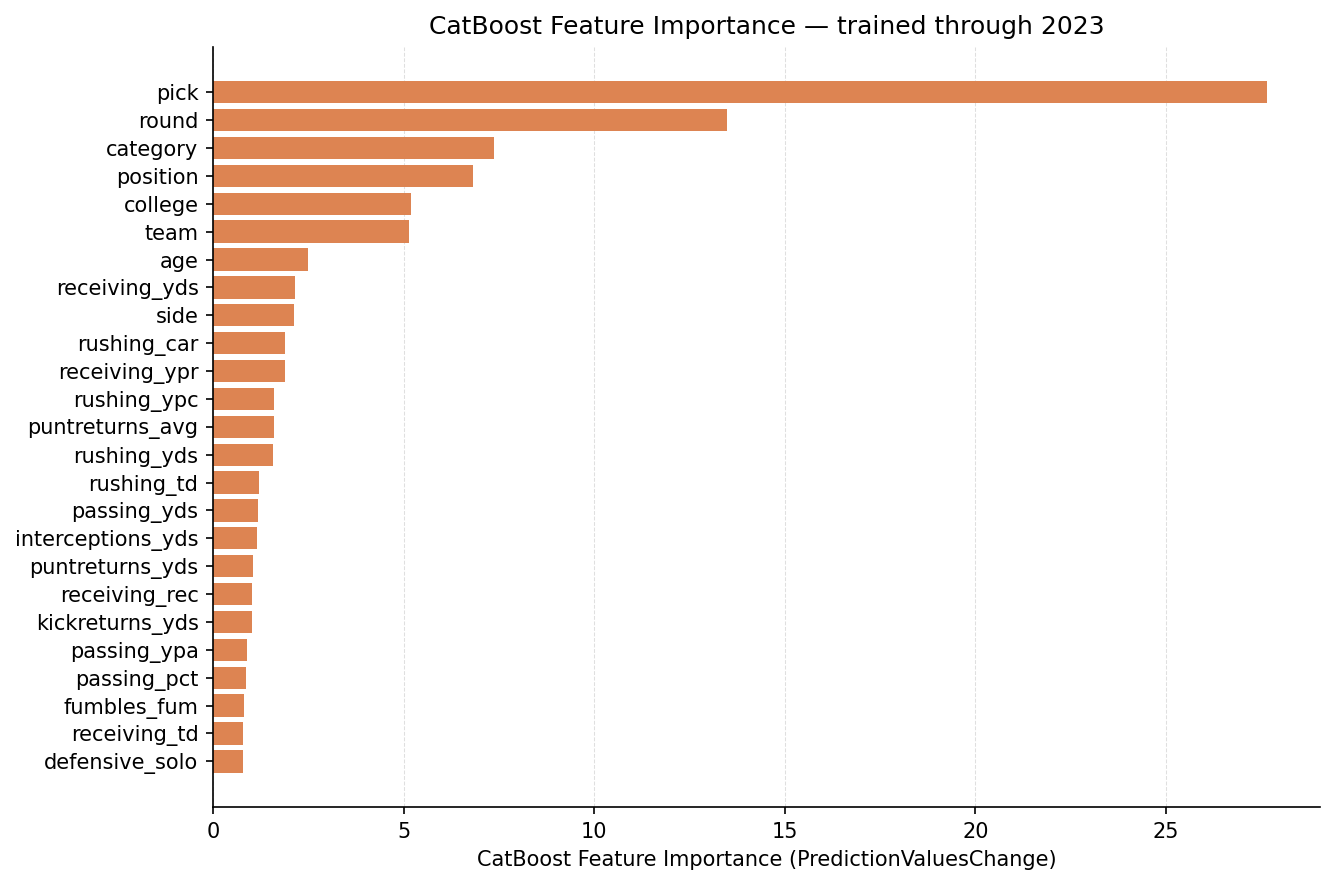

Top-10 features (CatBoost):
   1. pick                                     27.6551
   2. round                                    13.4748
   3. category                                 7.3726
   4. position                                 6.8194
   5. college                                  5.1982
   6. team                                     5.1338
   7. age                                      2.4906
   8. receiving_yds                            2.1434
   9. side                                     2.1172
  10. rushing_car                              1.8975


In [107]:
# CatBoost feature importance
cb_imp   = last['cb_model'].get_feature_importance()
cb_names = last['cb_feat_names']

idx_cb = np.argsort(cb_imp)[::-1][:top_n]
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
ax.barh([cb_names[i] for i in reversed(idx_cb)],
         cb_imp[list(reversed(idx_cb))], color='#DD8452')
ax.set_xlabel('CatBoost Feature Importance (PredictionValuesChange)')
ax.set_title(f'CatBoost Feature Importance — trained through {latest_year-1}')
ax.grid(True, axis='x', ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_catboost_feature_importance.png'), dpi=180)
plt.show()

print('Top-10 features (CatBoost):')
for rank, i in enumerate(idx_cb[:10], 1):
    print(f'  {rank:2d}. {cb_names[i]:<40s} {cb_imp[i]:.4f}')

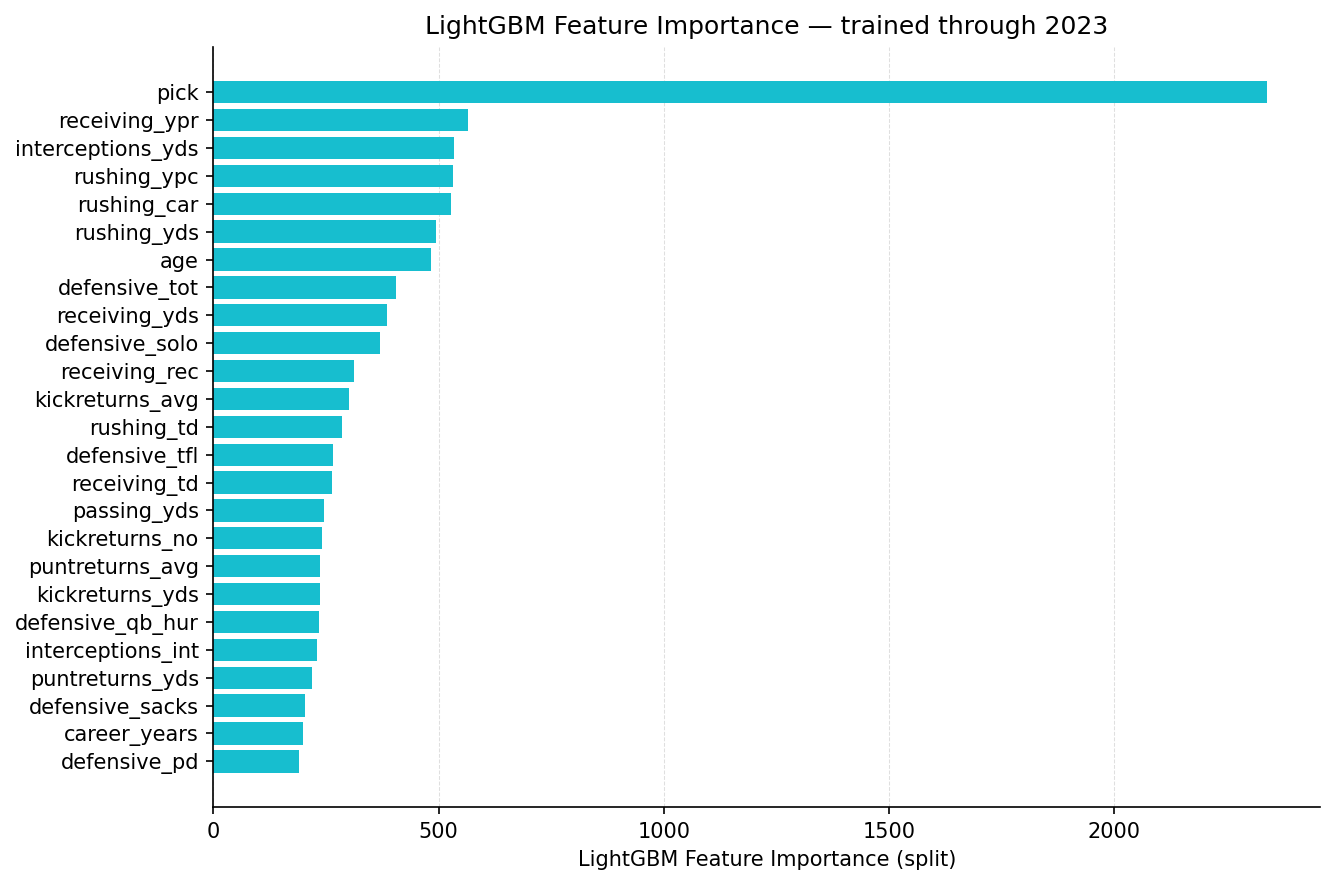

Top-10 features (LightGBM):
   1. pick                                     2340.0000
   2. receiving_ypr                            566.0000
   3. interceptions_yds                        535.0000
   4. rushing_ypc                              532.0000
   5. rushing_car                              527.0000
   6. rushing_yds                              494.0000
   7. age                                      484.0000
   8. defensive_tot                            406.0000
   9. receiving_yds                            385.0000
  10. defensive_solo                           370.0000


In [108]:
# LightGBM feature importance
lgbm_imp   = last['lgbm_pipe'].named_steps['lgbm'].feature_importances_
lgbm_names = get_feature_names(
    last['lgbm_pipe'].named_steps['pre'], last['num_lgbm'], last['cat_lgbm'])

idx_lgbm = np.argsort(lgbm_imp)[::-1][:top_n]
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
ax.barh([lgbm_names[i] for i in reversed(idx_lgbm)],
         lgbm_imp[list(reversed(idx_lgbm))], color='#17BECF')
ax.set_xlabel('LightGBM Feature Importance (split)')
ax.set_title(f'LightGBM Feature Importance — trained through {latest_year-1}')
ax.grid(True, axis='x', ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_lgbm_feature_importance.png'), dpi=180)
plt.show()

print('Top-10 features (LightGBM):')
for rank, i in enumerate(idx_lgbm[:10], 1):
    print(f'  {rank:2d}. {lgbm_names[i]:<40s} {lgbm_imp[i]:.4f}')

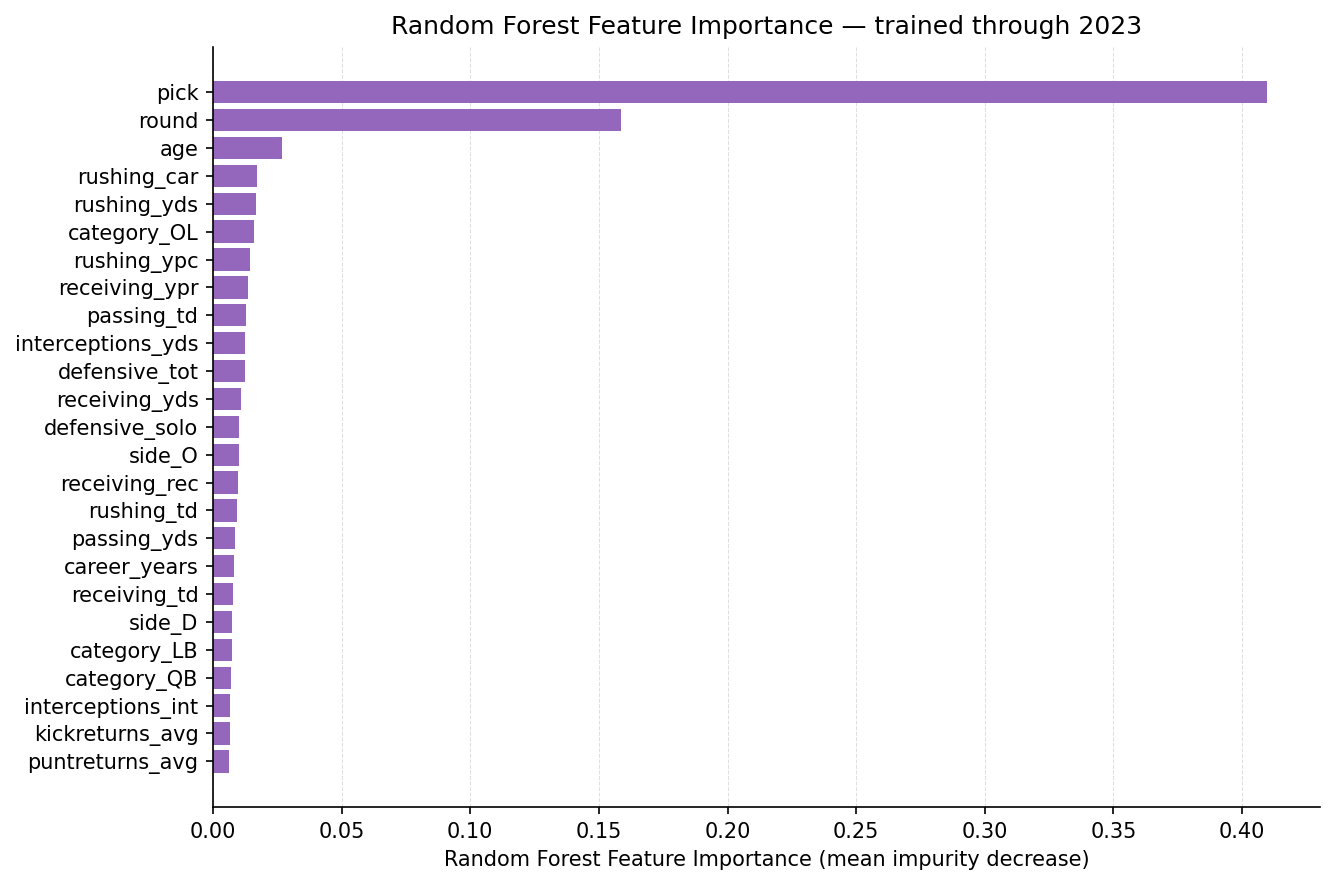

Top-10 features (Random Forest):
   1. pick                                     0.4098
   2. round                                    0.1586
   3. age                                      0.0270
   4. rushing_car                              0.0171
   5. rushing_yds                              0.0166
   6. category_OL                              0.0160
   7. rushing_ypc                              0.0143
   8. receiving_ypr                            0.0135
   9. passing_td                               0.0128
  10. interceptions_yds                        0.0123


In [109]:
# Random Forest feature importance
rf_imp   = last['rf_pipe'].named_steps['rf'].feature_importances_
rf_names = get_feature_names(
    last['rf_pipe'].named_steps['pre'], last['num_rf'], last['cat_rf'])

idx_rf = np.argsort(rf_imp)[::-1][:top_n]
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
ax.barh([rf_names[i] for i in reversed(idx_rf)],
         rf_imp[list(reversed(idx_rf))], color='#9467BD')
ax.set_xlabel('Random Forest Feature Importance (mean impurity decrease)')
ax.set_title(f'Random Forest Feature Importance — trained through {latest_year-1}')
ax.grid(True, axis='x', ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_rf_feature_importance.png'), dpi=180)
plt.show()

print('Top-10 features (Random Forest):')
for rank, i in enumerate(idx_rf[:10], 1):
    print(f'  {rank:2d}. {rf_names[i]:<40s} {rf_imp[i]:.4f}')

## 10. Walk-forward Metrics Over Time

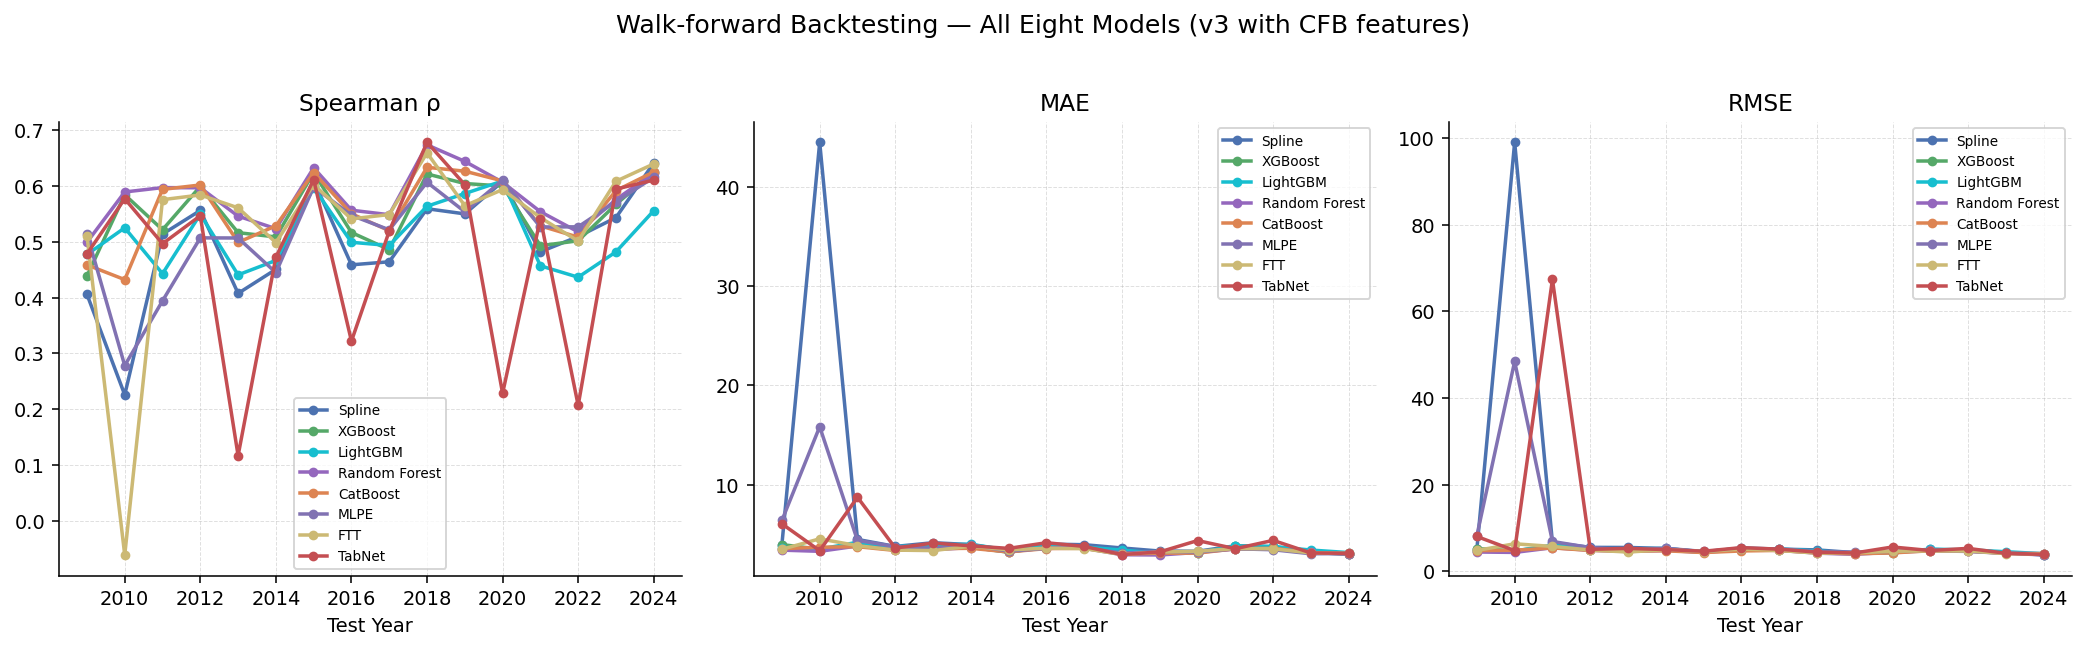

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=140)
metrics = [('spearman', 'Spearman ρ'), ('mae', 'MAE'), ('rmse', 'RMSE')]
colors  = {
    'spline':   '#4C72B0',
    'xgb':      '#55A868',
    'lgbm':     '#17BECF',
    'rf':       '#9467BD',
    'catboost': '#DD8452',
    'mlpe':     '#8172B2',
    'ftt':      '#CCB974',
    'tabnet':   '#C44E52',
}
labels = {
    'spline': 'Spline', 'xgb': 'XGBoost', 'lgbm': 'LightGBM', 'rf': 'Random Forest',
    'catboost': 'CatBoost', 'mlpe': 'MLPE', 'ftt': 'FTT', 'tabnet': 'TabNet',
}

for ax, (metric, label) in zip(axes, metrics):
    for model, color in colors.items():
        col = f'{model}_{metric}'
        ax.plot(res_df['test_year'], res_df[col], marker='o', lw=1.8, ms=4,
                label=labels[model], color=color)
    ax.set_title(label); ax.set_xlabel('Test Year')
    ax.legend(fontsize=7)
    ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
    for s in ['top','right']: ax.spines[s].set_visible(False)

fig.suptitle('Walk-forward Backtesting — All Eight Models (v3 with CFB features)', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_walkforward_metrics_v3.png'), dpi=180)
plt.show()

## 11. TabNet Attention Mask Visualisation (final fold)

In [111]:
# Rerun the final model on the test set to get step-level masks
pre_final, _nf, _cf = build_tree_preprocessor(X_raw[years < latest_year])
Xte_final = pre_final.fit_transform(X_raw[years == latest_year]).astype(np.float32)
feat_final = get_feature_names(pre_final, _nf, _cf)

n_show = min(40, len(Xte_final))
# Note: this reuses the last trained tabnet model
tabnet.eval()
with torch.no_grad():
    _, _, step_masks = tabnet(to_tensor(Xte_final[:n_show]).to(DEVICE))

top_feat_idx   = np.argsort(last['importance'])[::-1][:20]
top_feat_names = [feat_final[i] if i < len(feat_final) else '?' for i in top_feat_idx]

n_steps = len(step_masks)
fig, axes = plt.subplots(1, n_steps, figsize=(4 * n_steps, 5.5), dpi=120)
if n_steps == 1: axes = [axes]
for s, ax in enumerate(axes):
    M_s = step_masks[s].cpu().numpy()[:n_show, :][:, top_feat_idx]
    ax.imshow(M_s.T, aspect='auto', cmap='Blues', vmin=0, vmax=M_s.max())
    ax.set_title(f'Step {s+1}', fontsize=11)
    ax.set_xlabel('Sample index')
    ax.set_yticks(range(len(top_feat_names)))
    ax.set_yticklabels(top_feat_names, fontsize=7)
fig.suptitle(f'Attention masks — {latest_year} test class (top-20 features)', fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'plot_tabnet_masks_{latest_year}.png'), dpi=150)
plt.show()

RuntimeError: running_mean should contain 183 elements not 361

## 12. Hyperparameter Reference

| Parameter | Default | Effect |
|-----------|---------|--------|
| `n_d`, `n_a` | 16 | Decision/attention width. Larger = more capacity, slower. |
| `n_steps` | 4 | Sequential decision steps. 3–5 typical. |
| `gamma` | 1.5 | Prior scale relaxation. γ=1: each feature used once; γ→∞: no penalty. |
| `lambda_sparse` | 1e-3 | Sparsity reg. Higher = sparser masks. |
| `vbs` | 64 | Virtual batch size for Ghost BN. Keep < batch_size. |
| `FUZZY_THRESHOLD` | 85 | Minimum fuzzy match score (0–100). Lower = more matches, more noise. |
| `JOIN_ON_COLLEGE` | False | Requiring college match reduces coverage but improves precision. |